In [140]:
import pandas as pd
import lightgbm as lgb
from sklearn.pipeline import Pipeline
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from scripts import model_evaluation as model_eval

In [141]:
X_train = pd.read_parquet('X_train_cleaned.parquet')
X_test = pd.read_parquet('X_test_cleaned.parquet')

y_train = pd.read_parquet('y_train.parquet')
y_test = pd.read_parquet('y_test.parquet')

In [142]:
X_train.info()  

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 
 1

In [143]:
X_train.shape

(5634, 19)

In [144]:
cat_cols = ['PhoneService', 'MultipleLines', 'PaymentMethod',  
            'StreamingTV', 'OnlineSecurity', 'TechSupport',   
            'StreamingMovies', 'Contract', 'PaperlessBilling']

drop_cols = ['gender', 'Partner', 'Dependents',  'OnlineBackup', 'DeviceProtection', 'InternetService', 'TotalCharges']
    

In [145]:
cat_pipeline = Pipeline([
        ('ordinal_encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-2))
])

cat_feature_indices = list(range(len(cat_cols)))

In [146]:
preprocessor = ColumnTransformer([
    ('cat', cat_pipeline, cat_cols)
], remainder='passthrough')

In [147]:
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.cols)

In [148]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.tenure_max_ = None

    def fit(self, X, y=None):
        self.tenure_max_ = X['tenure'].max()
        self.monthly_charge_mean_ = X['MonthlyCharges'].mean()
        return self

    def transform(self, X):
        X = X.copy()

        service_usage_score = (
            (X[['StreamingTV','StreamingMovies','OnlineBackup',
                'DeviceProtection','TechSupport','OnlineSecurity', 
                'PhoneService']] == 'Yes').sum(axis=1)
        )

        service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                        'TechSupport', 'StreamingTV', 'StreamingMovies']
        service_adoption_rate = (X[service_cols] == 'Yes').sum(axis=1) / len(service_cols)

        X['service_usage_ratio'] = service_usage_score / (X['tenure'] + 1)

        X['charge_per_service'] = X['MonthlyCharges'] / (service_usage_score + 1)

        X['high_cost_short_tenure'] = X['MonthlyCharges'] * (X['tenure'] < 12)

        X['loyalty_index'] = (
            X['tenure'] *
            X['Contract'].map({'Month-to-month': 0.5, 'One year': 1.5, 'Two year': 3.0}) *
            (1 + service_adoption_rate)
        )

        X['longterm_customers'] = (
            (X['Contract'] != 'Month-to-month').astype(int) +
            (X['Dependents'] == 'Yes').astype(int) +
            (X['tenure'] >= 5).astype(int) +
            (X['tenure'] >= 24).astype(int) +
            (X['PaperlessBilling'] == 'No').astype(int)
        )

        X['risk_score'] = (
            (X['PaymentMethod'] == 'Electronic check').astype(int) +
            (X['PaperlessBilling'] == 'Yes').astype(int) +
            (X['MonthlyCharges'] > self.monthly_charge_mean_).astype(int) +
            (X['Contract'] == 'Month-to-month').astype(int)
        )

        X['missing_protection_score'] = (
            (X[['OnlineSecurity','TechSupport','OnlineBackup', 'DeviceProtection']] == 'No').sum(axis=1)
        )*X['MonthlyCharges']
    
        return X

In [149]:
model_pipeline = Pipeline([
    ('feature_engineering', FeatureEngineering()),
    ('drop_cols', DropColumns(cols=drop_cols)),
    ('preprocessing', preprocessor),
    ('model', lgb.LGBMClassifier(objective="binary", categorical_feature=cat_feature_indices))
])

In [151]:
def objective(trial):

    params = {
        "model__num_leaves":              trial.suggest_int("num_leaves", 15, 200),
        "model__max_depth":               trial.suggest_int("max_depth", 3, 12),
        "model__min_data_in_leaf":        trial.suggest_int("min_data_in_leaf", 10, 300),
        "model__n_estimators":            trial.suggest_int("n_estimators", 100, 1000),
        "model__learning_rate":           trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "model__subsample":               trial.suggest_float("subsample", .7, 1),
        "model__colsample_bytree":        trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "model__reg_alpha":               trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "model__reg_lambda":              trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "model__min_gain_to_split":       trial.suggest_float("min_gain_to_split", 0.0, 1.0),
        "model__path_smooth":             trial.suggest_float("path_smooth", 0.0, 1.0),
        "model__scale_pos_weight":        trial.suggest_float("scale_pos_weight", 1.0, 5.0),
    }

    max_leaves_allowed = 2 ** params["model__max_depth"] - 1
    if params["model__num_leaves"] > max_leaves_allowed * 1.5:
        raise optuna.TrialPruned()   

    pipeline = model_pipeline.set_params(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)

    return scores.mean()

In [ ]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10, n_startup_trials=10)
)

study.optimize(objective, n_trials=80, timeout=3600, show_progress_bar=True)

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\optuna\_experimental.py:33: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\optuna\_experimental.py:33: ExperimentalWarning:

Argument ``constant_liar`` is an experimental feature. The interface can change in the future.

[I 2026-05-06 21:19:37,751] A new study created in memory with name: no-name-50d83b3a-d698-43a5-992e-8deb1e83cb68
Best trial: 0. Best value: 0.689092:   2%|▎         | 2/80 [00:06<09:03,  6.97s/it, 6.97/3600 seconds]

[I 2026-05-06 21:19:44,717] Trial 0 finished with value: 0.6890917192079382 and parameters: {'num_leaves': 84, 'max_depth': 12, 'min_data_in_leaf': 223, 'n_estimators': 639, 'learning_rate': 0.00850018649460551, 'subsample': 0.7467983561008608, 'colsample_bytree': 0.7174250836504598, 'reg_alpha': 2.1423021757741068, 'reg_lambda': 0.10129197956845731, 'min_gain_to_split': 0.7080725777960455, 'path_smooth': 0.020584494295802447, 'scale_pos_weight': 4.879639408647977}. Best is trial 0 with value: 0.6890917192079382.
[I 2026-05-06 21:19:44,725] Trial 1 pruned. 


Best trial: 2. Best value: 0.710718:   8%|▊         | 6/80 [00:12<04:35,  3.73s/it, 12.17/3600 seconds]

[I 2026-05-06 21:19:49,898] Trial 2 finished with value: 0.7107178538743326 and parameters: {'num_leaves': 99, 'max_depth': 10, 'min_data_in_leaf': 68, 'n_estimators': 563, 'learning_rate': 0.037500594752084934, 'subsample': 0.7139351238159993, 'colsample_bytree': 0.8822634555704315, 'reg_alpha': 0.0007122305833333872, 'reg_lambda': 0.00021147447960615738, 'min_gain_to_split': 0.9488855372533332, 'path_smooth': 0.9656320330745594, 'scale_pos_weight': 4.233589392465845}. Best is trial 2 with value: 0.7107178538743326.
[I 2026-05-06 21:19:49,906] Trial 3 pruned. 
[I 2026-05-06 21:19:49,913] Trial 4 pruned. 
[I 2026-05-06 21:19:49,921] Trial 5 pruned. 


Best trial: 6. Best value: 0.736761:   9%|▉         | 7/80 [00:16<02:22,  1.95s/it, 16.60/3600 seconds]

[I 2026-05-06 21:19:54,352] Trial 6 finished with value: 0.7367613432892244 and parameters: {'num_leaves': 16, 'max_depth': 11, 'min_data_in_leaf': 215, 'n_estimators': 756, 'learning_rate': 0.06890168242875999, 'subsample': 0.7222133955202271, 'colsample_bytree': 0.8075397185632818, 'reg_alpha': 0.00037961668958008145, 'reg_lambda': 2.0678409397839492, 'min_gain_to_split': 0.6232981268275579, 'path_smooth': 0.3308980248526492, 'scale_pos_weight': 1.2542334011440945}. Best is trial 6 with value: 0.7367613432892244.


Best trial: 6. Best value: 0.736761:  10%|█         | 8/80 [00:20<02:50,  2.36s/it, 20.66/3600 seconds]

[I 2026-05-06 21:19:58,407] Trial 7 finished with value: 0.7190185838111115 and parameters: {'num_leaves': 72, 'max_depth': 6, 'min_data_in_leaf': 222, 'n_estimators': 674, 'learning_rate': 0.10220939176246895, 'subsample': 0.8416644775485848, 'colsample_bytree': 0.7358782737814905, 'reg_alpha': 0.36831884165358997, 'reg_lambda': 0.6366859160799433, 'min_gain_to_split': 0.5612771975694962, 'path_smooth': 0.770967179954561, 'scale_pos_weight': 2.975182385457563}. Best is trial 6 with value: 0.7367613432892244.


Best trial: 6. Best value: 0.736761:  12%|█▎        | 10/80 [00:23<02:57,  2.54s/it, 23.84/3600 seconds]

[I 2026-05-06 21:20:01,586] Trial 8 finished with value: 0.730353767108143 and parameters: {'num_leaves': 112, 'max_depth': 7, 'min_data_in_leaf': 17, 'n_estimators': 197, 'learning_rate': 0.005564097384419481, 'subsample': 0.8909231233791342, 'colsample_bytree': 0.794306794322898, 'reg_alpha': 0.03490225247838249, 'reg_lambda': 3.4501054536130167, 'min_gain_to_split': 0.24929222914887494, 'path_smooth': 0.41038292303562973, 'scale_pos_weight': 4.022204554172195}. Best is trial 6 with value: 0.7367613432892244.
[I 2026-05-06 21:20:01,594] Trial 9 pruned. 


Best trial: 6. Best value: 0.736761:  14%|█▍        | 11/80 [00:25<02:04,  1.81s/it, 25.10/3600 seconds]

[I 2026-05-06 21:20:02,845] Trial 10 finished with value: 0.7255231491352244 and parameters: {'num_leaves': 18, 'max_depth': 9, 'min_data_in_leaf': 154, 'n_estimators': 943, 'learning_rate': 0.0482206902433185, 'subsample': 0.7852167639162646, 'colsample_bytree': 0.987931223783626, 'reg_alpha': 0.00011365065005058419, 'reg_lambda': 0.0097423096918818, 'min_gain_to_split': 0.4197901175191579, 'path_smooth': 0.5904746895937296, 'scale_pos_weight': 1.034812514599746}. Best is trial 6 with value: 0.7367613432892244.


Best trial: 6. Best value: 0.736761:  15%|█▌        | 12/80 [00:26<01:59,  1.76s/it, 26.66/3600 seconds]

[I 2026-05-06 21:20:04,412] Trial 11 finished with value: 0.7106441535798493 and parameters: {'num_leaves': 141, 'max_depth': 8, 'min_data_in_leaf': 18, 'n_estimators': 118, 'learning_rate': 0.05224224265892445, 'subsample': 0.9132409945926143, 'colsample_bytree': 0.8005959014719353, 'reg_alpha': 0.03897587091961327, 'reg_lambda': 7.0322941350089065, 'min_gain_to_split': 0.3456937452482667, 'path_smooth': 0.37458564345214007, 'scale_pos_weight': 4.003474180811265}. Best is trial 6 with value: 0.7367613432892244.


Best trial: 6. Best value: 0.736761:  16%|█▋        | 13/80 [00:28<02:01,  1.82s/it, 28.68/3600 seconds]

[I 2026-05-06 21:20:06,436] Trial 12 finished with value: 0.7284998808538969 and parameters: {'num_leaves': 28, 'max_depth': 12, 'min_data_in_leaf': 150, 'n_estimators': 829, 'learning_rate': 0.02874349763142305, 'subsample': 0.7937060010630964, 'colsample_bytree': 0.788195257576149, 'reg_alpha': 0.031245726646903747, 'reg_lambda': 5.1686310615496, 'min_gain_to_split': 0.3305796679853259, 'path_smooth': 0.49708539361085247, 'scale_pos_weight': 1.138748711606981}. Best is trial 6 with value: 0.7367613432892244.


Best trial: 6. Best value: 0.736761:  18%|█▊        | 14/80 [00:35<03:28,  3.15s/it, 35.81/3600 seconds]

[I 2026-05-06 21:20:13,565] Trial 13 finished with value: 0.7149120873104748 and parameters: {'num_leaves': 135, 'max_depth': 10, 'min_data_in_leaf': 134, 'n_estimators': 997, 'learning_rate': 0.018203655911794528, 'subsample': 0.9037410766120517, 'colsample_bytree': 0.7974979023152108, 'reg_alpha': 0.03928594720806058, 'reg_lambda': 1.1244633416649683, 'min_gain_to_split': 0.034022340780253846, 'path_smooth': 0.19321912554519205, 'scale_pos_weight': 3.8414439250222525}. Best is trial 6 with value: 0.7367613432892244.


Best trial: 6. Best value: 0.736761:  19%|█▉        | 15/80 [00:37<03:03,  2.83s/it, 37.74/3600 seconds]

[I 2026-05-06 21:20:15,489] Trial 14 finished with value: 0.6978742486967343 and parameters: {'num_leaves': 189, 'max_depth': 7, 'min_data_in_leaf': 186, 'n_estimators': 362, 'learning_rate': 0.005270850754740867, 'subsample': 0.9931799396785234, 'colsample_bytree': 0.9404772831243063, 'reg_alpha': 0.0034636592245024076, 'reg_lambda': 0.26362969943410963, 'min_gain_to_split': 0.79903868834662, 'path_smooth': 0.4931262826571573, 'scale_pos_weight': 4.787219705654253}. Best is trial 6 with value: 0.7367613432892244.


Best trial: 6. Best value: 0.736761:  20%|██        | 16/80 [00:39<02:34,  2.42s/it, 39.07/3600 seconds]

[I 2026-05-06 21:20:16,821] Trial 15 finished with value: 0.7173055161335189 and parameters: {'num_leaves': 49, 'max_depth': 8, 'min_data_in_leaf': 13, 'n_estimators': 765, 'learning_rate': 0.08294915840775473, 'subsample': 0.7959018935867274, 'colsample_bytree': 0.7653369633997962, 'reg_alpha': 0.1467110653304528, 'reg_lambda': 9.860911359254892, 'min_gain_to_split': 0.5346635362676396, 'path_smooth': 0.628934326891659, 'scale_pos_weight': 3.517927867830905}. Best is trial 6 with value: 0.7367613432892244.


Best trial: 16. Best value: 0.740717:  21%|██▏       | 17/80 [00:39<02:02,  1.95s/it, 39.81/3600 seconds]

[I 2026-05-06 21:20:17,559] Trial 16 finished with value: 0.7407171355345122 and parameters: {'num_leaves': 120, 'max_depth': 10, 'min_data_in_leaf': 107, 'n_estimators': 119, 'learning_rate': 0.05733723411591337, 'subsample': 0.7099625672939907, 'colsample_bytree': 0.8425439821904961, 'reg_alpha': 0.00840408646231162, 'reg_lambda': 0.01355328687574815, 'min_gain_to_split': 0.4242116561992394, 'path_smooth': 0.19653820123064533, 'scale_pos_weight': 1.6197384996618194}. Best is trial 16 with value: 0.7407171355345122.


Best trial: 17. Best value: 0.741222:  22%|██▎       | 18/80 [00:40<01:44,  1.68s/it, 40.84/3600 seconds]

[I 2026-05-06 21:20:18,591] Trial 17 finished with value: 0.7412216139688885 and parameters: {'num_leaves': 148, 'max_depth': 11, 'min_data_in_leaf': 111, 'n_estimators': 684, 'learning_rate': 0.06717858252036424, 'subsample': 0.7084067876016337, 'colsample_bytree': 0.844383284826441, 'reg_alpha': 0.0001024006186100508, 'reg_lambda': 0.00863710433299605, 'min_gain_to_split': 0.45358908779006013, 'path_smooth': 0.1897347654571661, 'scale_pos_weight': 1.7627440020999028}. Best is trial 17 with value: 0.7412216139688885.


Best trial: 18. Best value: 0.74175:  24%|██▍       | 19/80 [00:41<01:29,  1.47s/it, 41.78/3600 seconds] 

[I 2026-05-06 21:20:19,532] Trial 18 finished with value: 0.7417501280422096 and parameters: {'num_leaves': 156, 'max_depth': 10, 'min_data_in_leaf': 113, 'n_estimators': 368, 'learning_rate': 0.06561010676098017, 'subsample': 0.7564035632103615, 'colsample_bytree': 0.8468463726321205, 'reg_alpha': 0.0027306892114037666, 'reg_lambda': 0.009826290998413903, 'min_gain_to_split': 0.45014600639017166, 'path_smooth': 0.15361489704907913, 'scale_pos_weight': 1.7496483855788036}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  25%|██▌       | 20/80 [00:43<01:30,  1.50s/it, 43.37/3600 seconds]

[I 2026-05-06 21:20:21,121] Trial 19 finished with value: 0.7318734641732618 and parameters: {'num_leaves': 167, 'max_depth': 11, 'min_data_in_leaf': 114, 'n_estimators': 366, 'learning_rate': 0.033419625772743315, 'subsample': 0.7562261670672006, 'colsample_bytree': 0.9256070219195369, 'reg_alpha': 0.0001310835848259471, 'reg_lambda': 0.0019090010173400097, 'min_gain_to_split': 0.5073121999753731, 'path_smooth': 0.14404233416274695, 'scale_pos_weight': 2.0942891151457945}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  26%|██▋       | 21/80 [00:45<01:45,  1.79s/it, 45.85/3600 seconds]

[I 2026-05-06 21:20:23,600] Trial 20 finished with value: 0.7257316568745994 and parameters: {'num_leaves': 200, 'max_depth': 9, 'min_data_in_leaf': 65, 'n_estimators': 519, 'learning_rate': 0.023486959939674062, 'subsample': 0.7545962189447302, 'colsample_bytree': 0.8566296868915504, 'reg_alpha': 0.0009707446924431997, 'reg_lambda': 0.002855015469645266, 'min_gain_to_split': 0.7731635248800401, 'path_smooth': 0.10338451302751478, 'scale_pos_weight': 2.6490110480515683}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  28%|██▊       | 22/80 [00:46<01:29,  1.54s/it, 46.80/3600 seconds]

[I 2026-05-06 21:20:24,549] Trial 21 finished with value: 0.7400642719067919 and parameters: {'num_leaves': 142, 'max_depth': 10, 'min_data_in_leaf': 102, 'n_estimators': 122, 'learning_rate': 0.06551515282125005, 'subsample': 0.7085396289962766, 'colsample_bytree': 0.8383212696203702, 'reg_alpha': 0.005617117366418254, 'reg_lambda': 0.0196435655073421, 'min_gain_to_split': 0.41916396011530194, 'path_smooth': 0.19632564439341238, 'scale_pos_weight': 1.7083568540256038}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  29%|██▉       | 23/80 [00:48<01:27,  1.53s/it, 48.31/3600 seconds]

[I 2026-05-06 21:20:26,061] Trial 22 finished with value: 0.7372422014198319 and parameters: {'num_leaves': 165, 'max_depth': 11, 'min_data_in_leaf': 123, 'n_estimators': 630, 'learning_rate': 0.04803011069530038, 'subsample': 0.7351140885870441, 'colsample_bytree': 0.8591967050093969, 'reg_alpha': 0.009270949652574814, 'reg_lambda': 0.00841568181140913, 'min_gain_to_split': 0.4179050271375795, 'path_smooth': 0.2354184852213661, 'scale_pos_weight': 1.6495967546787051}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  30%|███       | 24/80 [00:48<01:11,  1.28s/it, 48.99/3600 seconds]

[I 2026-05-06 21:20:26,737] Trial 23 finished with value: 0.7395209166761656 and parameters: {'num_leaves': 127, 'max_depth': 9, 'min_data_in_leaf': 172, 'n_estimators': 308, 'learning_rate': 0.14352501999667952, 'subsample': 0.7741372609521419, 'colsample_bytree': 0.9136693789502349, 'reg_alpha': 0.0014272156466515829, 'reg_lambda': 0.02901637484859282, 'min_gain_to_split': 0.3408067858950773, 'path_smooth': 0.12034916230868845, 'scale_pos_weight': 1.4275512741064336}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  31%|███▏      | 25/80 [00:50<01:09,  1.27s/it, 50.23/3600 seconds]

[I 2026-05-06 21:20:27,985] Trial 24 finished with value: 0.7324821452758855 and parameters: {'num_leaves': 152, 'max_depth': 12, 'min_data_in_leaf': 83, 'n_estimators': 479, 'learning_rate': 0.0833614835675856, 'subsample': 0.7027626060079805, 'colsample_bytree': 0.8332003578683135, 'reg_alpha': 0.013088503110147512, 'reg_lambda': 0.0007840851801226458, 'min_gain_to_split': 0.4542216849011833, 'path_smooth': 0.2386044140905518, 'scale_pos_weight': 2.022743459014942}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  32%|███▎      | 26/80 [00:51<01:11,  1.32s/it, 51.66/3600 seconds]

[I 2026-05-06 21:20:29,409] Trial 25 finished with value: 0.7377860839826234 and parameters: {'num_leaves': 152, 'max_depth': 10, 'min_data_in_leaf': 51, 'n_estimators': 418, 'learning_rate': 0.060142024774484666, 'subsample': 0.8085892402076451, 'colsample_bytree': 0.8201121775997783, 'reg_alpha': 0.0003357827685763172, 'reg_lambda': 0.0076054252978250865, 'min_gain_to_split': 0.5734037667450476, 'path_smooth': 0.07941592031578897, 'scale_pos_weight': 1.572484424490634}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  34%|███▍      | 27/80 [00:53<01:13,  1.39s/it, 53.23/3600 seconds]

[I 2026-05-06 21:20:30,976] Trial 26 finished with value: 0.7245178771445235 and parameters: {'num_leaves': 120, 'max_depth': 11, 'min_data_in_leaf': 135, 'n_estimators': 189, 'learning_rate': 0.041396421878328725, 'subsample': 0.7317469040508647, 'colsample_bytree': 0.863202403979488, 'reg_alpha': 0.002408852620136511, 'reg_lambda': 0.05412692093750442, 'min_gain_to_split': 0.3246740768664066, 'path_smooth': 0.006420632018683592, 'scale_pos_weight': 2.697847388383272}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  35%|███▌      | 28/80 [00:54<01:14,  1.44s/it, 54.77/3600 seconds]

[I 2026-05-06 21:20:32,522] Trial 27 finished with value: 0.7355055353769091 and parameters: {'num_leaves': 182, 'max_depth': 9, 'min_data_in_leaf': 43, 'n_estimators': 601, 'learning_rate': 0.08610825767743104, 'subsample': 0.8178893973722072, 'colsample_bytree': 0.7705604240531897, 'reg_alpha': 0.16752588811922892, 'reg_lambda': 0.004052244430896549, 'min_gain_to_split': 0.26056403462227384, 'path_smooth': 0.4169745883200573, 'scale_pos_weight': 2.027268448225584}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  36%|███▋      | 29/80 [00:56<01:24,  1.65s/it, 56.92/3600 seconds]

[I 2026-05-06 21:20:34,671] Trial 28 finished with value: 0.7334409014544161 and parameters: {'num_leaves': 154, 'max_depth': 8, 'min_data_in_leaf': 88, 'n_estimators': 708, 'learning_rate': 0.025150684082263633, 'subsample': 0.768033668119244, 'colsample_bytree': 0.9628160833474195, 'reg_alpha': 0.00024061315742047624, 'reg_lambda': 0.0008208422844533558, 'min_gain_to_split': 0.4651095838868903, 'path_smooth': 0.16008204370259835, 'scale_pos_weight': 1.4041478888248706}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  38%|███▊      | 30/80 [00:58<01:15,  1.50s/it, 58.08/3600 seconds]

[I 2026-05-06 21:20:35,824] Trial 29 finished with value: 0.7312750709260056 and parameters: {'num_leaves': 100, 'max_depth': 12, 'min_data_in_leaf': 172, 'n_estimators': 883, 'learning_rate': 0.07057787253932185, 'subsample': 0.738075379608956, 'colsample_bytree': 0.8980241782303763, 'reg_alpha': 0.01418256067743519, 'reg_lambda': 0.09404069704936542, 'min_gain_to_split': 0.7362118588594929, 'path_smooth': 0.2616851450168089, 'scale_pos_weight': 2.3146648097486677}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  39%|███▉      | 31/80 [00:58<01:01,  1.26s/it, 58.76/3600 seconds]

[I 2026-05-06 21:20:36,507] Trial 30 finished with value: 0.7382228794659025 and parameters: {'num_leaves': 128, 'max_depth': 11, 'min_data_in_leaf': 116, 'n_estimators': 185, 'learning_rate': 0.09865754816716495, 'subsample': 0.7004874371638535, 'colsample_bytree': 0.8707998705040101, 'reg_alpha': 0.0006636508737346407, 'reg_lambda': 0.013462057767584981, 'min_gain_to_split': 0.6013335168313414, 'path_smooth': 0.04620800648585929, 'scale_pos_weight': 1.9577875997805143}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  40%|████      | 32/80 [00:59<00:56,  1.18s/it, 59.75/3600 seconds]

[I 2026-05-06 21:20:37,494] Trial 31 finished with value: 0.7401422022798234 and parameters: {'num_leaves': 140, 'max_depth': 10, 'min_data_in_leaf': 102, 'n_estimators': 116, 'learning_rate': 0.0568732945820393, 'subsample': 0.7208160624996618, 'colsample_bytree': 0.8417192178743469, 'reg_alpha': 0.005556201155626487, 'reg_lambda': 0.021366355593390687, 'min_gain_to_split': 0.3772151465391174, 'path_smooth': 0.2057284910122863, 'scale_pos_weight': 1.7507809406010648}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  41%|████▏     | 33/80 [01:00<00:54,  1.15s/it, 60.83/3600 seconds]

[I 2026-05-06 21:20:38,585] Trial 32 finished with value: 0.738648246357831 and parameters: {'num_leaves': 173, 'max_depth': 10, 'min_data_in_leaf': 106, 'n_estimators': 282, 'learning_rate': 0.05688373442208861, 'subsample': 0.7515596465450726, 'colsample_bytree': 0.8441154697203337, 'reg_alpha': 0.005891038689815179, 'reg_lambda': 0.026495038169275027, 'min_gain_to_split': 0.38652804124276885, 'path_smooth': 0.3461861070255564, 'scale_pos_weight': 1.4010573070402352}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  42%|████▎     | 34/80 [01:02<00:55,  1.22s/it, 62.20/3600 seconds]

[I 2026-05-06 21:20:39,953] Trial 33 finished with value: 0.7398292400395228 and parameters: {'num_leaves': 156, 'max_depth': 9, 'min_data_in_leaf': 76, 'n_estimators': 122, 'learning_rate': 0.040119436940969574, 'subsample': 0.7219186527331886, 'colsample_bytree': 0.8234777696836177, 'reg_alpha': 0.08812226600022618, 'reg_lambda': 0.05476395026435405, 'min_gain_to_split': 0.4757400741624323, 'path_smooth': 0.20842060175092186, 'scale_pos_weight': 1.8210890527272021}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  44%|████▍     | 35/80 [01:04<01:04,  1.43s/it, 64.15/3600 seconds]

[I 2026-05-06 21:20:41,897] Trial 34 finished with value: 0.7295650614306192 and parameters: {'num_leaves': 100, 'max_depth': 10, 'min_data_in_leaf': 140, 'n_estimators': 251, 'learning_rate': 0.031547698345968905, 'subsample': 0.7211362722700587, 'colsample_bytree': 0.9055496939945411, 'reg_alpha': 0.0020727997785859598, 'reg_lambda': 0.22591190875854197, 'min_gain_to_split': 0.2584478193402281, 'path_smooth': 0.270737739018465, 'scale_pos_weight': 2.392998322321569}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  45%|████▌     | 36/80 [01:05<01:02,  1.42s/it, 65.55/3600 seconds]

[I 2026-05-06 21:20:43,301] Trial 35 finished with value: 0.7315834901589339 and parameters: {'num_leaves': 137, 'max_depth': 12, 'min_data_in_leaf': 126, 'n_estimators': 569, 'learning_rate': 0.043832786522293235, 'subsample': 0.7449919059293932, 'colsample_bytree': 0.8494257512943597, 'reg_alpha': 0.004421902281223398, 'reg_lambda': 0.003953430517943766, 'min_gain_to_split': 0.6716039467596424, 'path_smooth': 0.13374452795806502, 'scale_pos_weight': 2.2050338467436283}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  46%|████▋     | 37/80 [01:08<01:24,  1.96s/it, 68.76/3600 seconds]

[I 2026-05-06 21:20:46,510] Trial 36 finished with value: 0.7119852340071595 and parameters: {'num_leaves': 123, 'max_depth': 11, 'min_data_in_leaf': 41, 'n_estimators': 329, 'learning_rate': 0.07610223322253902, 'subsample': 0.7696620854427091, 'colsample_bytree': 0.815907055160598, 'reg_alpha': 0.017482767246811796, 'reg_lambda': 0.053790693849403805, 'min_gain_to_split': 0.07405268618621558, 'path_smooth': 0.31179770088676406, 'scale_pos_weight': 2.579589294427583}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  48%|████▊     | 38/80 [01:09<01:07,  1.62s/it, 69.57/3600 seconds]

[I 2026-05-06 21:20:47,324] Trial 37 finished with value: 0.7311849832676571 and parameters: {'num_leaves': 89, 'max_depth': 10, 'min_data_in_leaf': 169, 'n_estimators': 431, 'learning_rate': 0.14821583514120074, 'subsample': 0.7162049089861361, 'colsample_bytree': 0.8762707816492836, 'reg_alpha': 0.008425251894316383, 'reg_lambda': 0.0006822366121405258, 'min_gain_to_split': 0.29235966750867065, 'path_smooth': 0.0770659224214322, 'scale_pos_weight': 1.8698268678246053}. Best is trial 18 with value: 0.7417501280422096.


Best trial: 18. Best value: 0.74175:  50%|█████     | 40/80 [01:10<00:52,  1.31s/it, 70.20/3600 seconds]

[I 2026-05-06 21:20:47,905] Trial 38 finished with value: 0.735682414157693 and parameters: {'num_leaves': 111, 'max_depth': 11, 'min_data_in_leaf': 194, 'n_estimators': 170, 'learning_rate': 0.10477726563340932, 'subsample': 0.7292121784809469, 'colsample_bytree': 0.7762489233304875, 'reg_alpha': 0.0006544083817508766, 'reg_lambda': 0.00568562475001927, 'min_gain_to_split': 0.5191178274516738, 'path_smooth': 0.4389413224893087, 'scale_pos_weight': 1.2678493554345227}. Best is trial 18 with value: 0.7417501280422096.
[I 2026-05-06 21:20:47,948] Trial 39 pruned. 


Best trial: 40. Best value: 0.744557:  51%|█████▏    | 41/80 [01:10<00:33,  1.17it/s, 70.82/3600 seconds]

[I 2026-05-06 21:20:48,570] Trial 40 finished with value: 0.7445574583320649 and parameters: {'num_leaves': 162, 'max_depth': 9, 'min_data_in_leaf': 293, 'n_estimators': 224, 'learning_rate': 0.058723953953760406, 'subsample': 0.7634150102648737, 'colsample_bytree': 0.8797422627295498, 'reg_alpha': 8.86833149829262, 'reg_lambda': 0.02002193030466143, 'min_gain_to_split': 0.17799585168338006, 'path_smooth': 0.1767412989070274, 'scale_pos_weight': 1.5684386059576687}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  52%|█████▎    | 42/80 [01:12<00:35,  1.06it/s, 72.02/3600 seconds]

[I 2026-05-06 21:20:49,768] Trial 41 finished with value: 0.7389642480991092 and parameters: {'num_leaves': 162, 'max_depth': 10, 'min_data_in_leaf': 252, 'n_estimators': 231, 'learning_rate': 0.06108866074346476, 'subsample': 0.7459329306099525, 'colsample_bytree': 0.8554451623745751, 'reg_alpha': 0.9876148663004867, 'reg_lambda': 0.014988769005443606, 'min_gain_to_split': 0.11735862494180654, 'path_smooth': 0.19521663354247895, 'scale_pos_weight': 1.5650375879648328}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  54%|█████▍    | 43/80 [01:12<00:31,  1.17it/s, 72.62/3600 seconds]

[I 2026-05-06 21:20:50,369] Trial 42 finished with value: 0.74155204307734 and parameters: {'num_leaves': 179, 'max_depth': 9, 'min_data_in_leaf': 264, 'n_estimators': 161, 'learning_rate': 0.054342498065304654, 'subsample': 0.7013535093467439, 'colsample_bytree': 0.8785999631840625, 'reg_alpha': 8.595533338221845, 'reg_lambda': 0.11412381245577546, 'min_gain_to_split': 0.20960486255263114, 'path_smooth': 0.16274128541401184, 'scale_pos_weight': 1.2505586233831587}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  55%|█████▌    | 44/80 [01:13<00:29,  1.23it/s, 73.32/3600 seconds]

[I 2026-05-06 21:20:51,067] Trial 43 finished with value: 0.7374263145770494 and parameters: {'num_leaves': 172, 'max_depth': 8, 'min_data_in_leaf': 296, 'n_estimators': 162, 'learning_rate': 0.033716552202524515, 'subsample': 0.7031229323775299, 'colsample_bytree': 0.8862204100553397, 'reg_alpha': 5.671756558468329, 'reg_lambda': 0.1710170657020578, 'min_gain_to_split': 0.1964765189146547, 'path_smooth': 0.030325986960169, 'scale_pos_weight': 1.1868242467979455}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  56%|█████▋    | 45/80 [01:14<00:27,  1.28it/s, 74.02/3600 seconds]

[I 2026-05-06 21:20:51,765] Trial 44 finished with value: 0.732360165711679 and parameters: {'num_leaves': 181, 'max_depth': 9, 'min_data_in_leaf': 273, 'n_estimators': 228, 'learning_rate': 0.048647106383412395, 'subsample': 0.8631861063590456, 'colsample_bytree': 0.8711519286431804, 'reg_alpha': 9.76137198095341, 'reg_lambda': 0.089730195194203, 'min_gain_to_split': 0.17719992058967643, 'path_smooth': 0.1547574062812587, 'scale_pos_weight': 1.0799985487620127}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  59%|█████▉    | 47/80 [01:15<00:27,  1.20it/s, 75.04/3600 seconds]

[I 2026-05-06 21:20:52,742] Trial 45 finished with value: 0.7344749702332699 and parameters: {'num_leaves': 178, 'max_depth': 9, 'min_data_in_leaf': 279, 'n_estimators': 289, 'learning_rate': 0.09396589043844542, 'subsample': 0.7825548785889169, 'colsample_bytree': 0.9214986610315054, 'reg_alpha': 0.7837003458779294, 'reg_lambda': 0.00011764881799576805, 'min_gain_to_split': 0.14921556092300464, 'path_smooth': 0.35268942385567603, 'scale_pos_weight': 1.4631651987466838}. Best is trial 40 with value: 0.7445574583320649.
[I 2026-05-06 21:20:52,790] Trial 46 pruned. 


Best trial: 40. Best value: 0.744557:  60%|██████    | 48/80 [01:15<00:21,  1.46it/s, 75.98/3600 seconds]

[I 2026-05-06 21:20:53,732] Trial 47 finished with value: 0.7407495408190913 and parameters: {'num_leaves': 190, 'max_depth': 8, 'min_data_in_leaf': 271, 'n_estimators': 349, 'learning_rate': 0.0699705446910683, 'subsample': 0.7352099988465015, 'colsample_bytree': 0.809364904416621, 'reg_alpha': 1.6404085501148309, 'reg_lambda': 0.033731209874901094, 'min_gain_to_split': 0.22700772509095793, 'path_smooth': 0.9985364655754743, 'scale_pos_weight': 1.6064135233424794}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  64%|██████▍   | 51/80 [01:17<00:28,  1.03it/s, 77.95/3600 seconds]

[I 2026-05-06 21:20:55,603] Trial 48 finished with value: 0.7180254949369643 and parameters: {'num_leaves': 188, 'max_depth': 8, 'min_data_in_leaf': 278, 'n_estimators': 374, 'learning_rate': 0.07651242405869718, 'subsample': 0.7385141662156558, 'colsample_bytree': 0.8099183778968926, 'reg_alpha': 1.6158018312041549, 'reg_lambda': 0.05283474512475052, 'min_gain_to_split': 0.024807999849543516, 'path_smooth': 0.9743521014158754, 'scale_pos_weight': 3.3963141900744125}. Best is trial 40 with value: 0.7445574583320649.
[I 2026-05-06 21:20:55,653] Trial 49 pruned. 
[I 2026-05-06 21:20:55,696] Trial 50 pruned. 


Best trial: 40. Best value: 0.744557:  65%|██████▌   | 52/80 [01:18<00:17,  1.64it/s, 78.63/3600 seconds]

[I 2026-05-06 21:20:56,385] Trial 51 finished with value: 0.7331446401490817 and parameters: {'num_leaves': 161, 'max_depth': 9, 'min_data_in_leaf': 290, 'n_estimators': 164, 'learning_rate': 0.06645155180014788, 'subsample': 0.7169921915110855, 'colsample_bytree': 0.8286675173822415, 'reg_alpha': 5.079922085322357, 'reg_lambda': 0.011881667280364031, 'min_gain_to_split': 0.3033850188482051, 'path_smooth': 0.5608182937946797, 'scale_pos_weight': 2.189507120566888}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  66%|██████▋   | 53/80 [01:19<00:18,  1.43it/s, 79.70/3600 seconds]

[I 2026-05-06 21:20:57,450] Trial 52 finished with value: 0.7419440242667925 and parameters: {'num_leaves': 173, 'max_depth': 8, 'min_data_in_leaf': 268, 'n_estimators': 264, 'learning_rate': 0.051906243773972634, 'subsample': 0.7286764509240286, 'colsample_bytree': 0.8682210987105, 'reg_alpha': 2.275115900033187, 'reg_lambda': 0.00580057563067039, 'min_gain_to_split': 0.19904514098258172, 'path_smooth': 0.9104592533447607, 'scale_pos_weight': 1.5337062293095514}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  68%|██████▊   | 54/80 [01:20<00:20,  1.25it/s, 80.87/3600 seconds]

[I 2026-05-06 21:20:58,620] Trial 53 finished with value: 0.7421856688893994 and parameters: {'num_leaves': 174, 'max_depth': 8, 'min_data_in_leaf': 259, 'n_estimators': 391, 'learning_rate': 0.04989213239521926, 'subsample': 0.7293279815631223, 'colsample_bytree': 0.8794108663532695, 'reg_alpha': 3.324422626123029, 'reg_lambda': 0.0072171613877920855, 'min_gain_to_split': 0.15432127759352104, 'path_smooth': 0.9252597051824996, 'scale_pos_weight': 1.5117793024293706}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  69%|██████▉   | 55/80 [01:21<00:21,  1.14it/s, 81.99/3600 seconds]

[I 2026-05-06 21:20:59,739] Trial 54 finished with value: 0.7381068753667573 and parameters: {'num_leaves': 174, 'max_depth': 7, 'min_data_in_leaf': 229, 'n_estimators': 391, 'learning_rate': 0.051868903146931794, 'subsample': 0.7605477484004515, 'colsample_bytree': 0.897565919519903, 'reg_alpha': 2.723582715569944, 'reg_lambda': 0.005676840589276828, 'min_gain_to_split': 0.15506797803680822, 'path_smooth': 0.8778125735172065, 'scale_pos_weight': 1.2530362721047532}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  70%|███████   | 56/80 [01:24<00:29,  1.23s/it, 84.28/3600 seconds]

[I 2026-05-06 21:21:02,025] Trial 55 finished with value: 0.6984557798397025 and parameters: {'num_leaves': 165, 'max_depth': 8, 'min_data_in_leaf': 207, 'n_estimators': 534, 'learning_rate': 0.05340027942740454, 'subsample': 0.7479369917618264, 'colsample_bytree': 0.9380654653437855, 'reg_alpha': 5.194887145325275, 'reg_lambda': 0.0028450378934664696, 'min_gain_to_split': 0.05107516129134122, 'path_smooth': 0.9267496034215101, 'scale_pos_weight': 4.568638744423264}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  71%|███████▏  | 57/80 [01:25<00:30,  1.32s/it, 85.83/3600 seconds]

[I 2026-05-06 21:21:03,579] Trial 56 finished with value: 0.7436418896312038 and parameters: {'num_leaves': 182, 'max_depth': 9, 'min_data_in_leaf': 258, 'n_estimators': 268, 'learning_rate': 0.04433174193035625, 'subsample': 0.7779791663178877, 'colsample_bytree': 0.8781259910877749, 'reg_alpha': 6.566684085853871, 'reg_lambda': 0.007450091045649778, 'min_gain_to_split': 0.11624105318249307, 'path_smooth': 0.8515935119591536, 'scale_pos_weight': 1.5054474888619005}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  72%|███████▎  | 58/80 [01:27<00:28,  1.29s/it, 87.03/3600 seconds]

[I 2026-05-06 21:21:04,783] Trial 57 finished with value: 0.7432350780802572 and parameters: {'num_leaves': 181, 'max_depth': 9, 'min_data_in_leaf': 257, 'n_estimators': 268, 'learning_rate': 0.04551764245432404, 'subsample': 0.7808384198396993, 'colsample_bytree': 0.8810721483343245, 'reg_alpha': 6.755910025063023, 'reg_lambda': 0.0014644303242205639, 'min_gain_to_split': 0.11727049676565096, 'path_smooth': 0.8459640095069142, 'scale_pos_weight': 1.4905957426142764}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  75%|███████▌  | 60/80 [01:29<00:29,  1.48s/it, 89.07/3600 seconds]

[I 2026-05-06 21:21:06,759] Trial 58 finished with value: 0.7369161459404949 and parameters: {'num_leaves': 182, 'max_depth': 8, 'min_data_in_leaf': 252, 'n_estimators': 318, 'learning_rate': 0.0452212074924731, 'subsample': 0.8314474336395501, 'colsample_bytree': 0.909575042097032, 'reg_alpha': 1.9531541524747984, 'reg_lambda': 0.0014115510477913432, 'min_gain_to_split': 0.004428981176846036, 'path_smooth': 0.8329482368564207, 'scale_pos_weight': 1.4961278920439334}. Best is trial 40 with value: 0.7445574583320649.
[I 2026-05-06 21:21:06,818] Trial 59 pruned. 


Best trial: 40. Best value: 0.744557:  76%|███████▋  | 61/80 [01:30<00:21,  1.14s/it, 90.43/3600 seconds]

[I 2026-05-06 21:21:08,174] Trial 60 finished with value: 0.7410282359972543 and parameters: {'num_leaves': 170, 'max_depth': 9, 'min_data_in_leaf': 220, 'n_estimators': 280, 'learning_rate': 0.034792880971620484, 'subsample': 0.7777400502032709, 'colsample_bytree': 0.8860383253601934, 'reg_alpha': 6.405240082781986, 'reg_lambda': 0.00037585374604895964, 'min_gain_to_split': 0.07098925141113235, 'path_smooth': 0.9102289003383608, 'scale_pos_weight': 1.374724119918817}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  78%|███████▊  | 62/80 [01:31<00:19,  1.10s/it, 91.41/3600 seconds]

[I 2026-05-06 21:21:09,155] Trial 61 finished with value: 0.7402850272341419 and parameters: {'num_leaves': 178, 'max_depth': 9, 'min_data_in_leaf': 263, 'n_estimators': 307, 'learning_rate': 0.0385502488089554, 'subsample': 0.7646748523559955, 'colsample_bytree': 0.8794731980323522, 'reg_alpha': 7.766981237928251, 'reg_lambda': 0.0030740467054225897, 'min_gain_to_split': 0.19263036420366814, 'path_smooth': 0.8144303117607795, 'scale_pos_weight': 1.205303757992603}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  79%|███████▉  | 63/80 [01:32<00:17,  1.06s/it, 92.34/3600 seconds]

[I 2026-05-06 21:21:10,091] Trial 62 finished with value: 0.7278628810027549 and parameters: {'num_leaves': 159, 'max_depth': 9, 'min_data_in_leaf': 259, 'n_estimators': 403, 'learning_rate': 0.04524512081802188, 'subsample': 0.7977568273896076, 'colsample_bytree': 0.9021043372405587, 'reg_alpha': 4.081855920551722, 'reg_lambda': 0.0020240394201819006, 'min_gain_to_split': 0.8539883625040152, 'path_smooth': 0.7276688751564349, 'scale_pos_weight': 1.001826169910053}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  80%|████████  | 64/80 [01:33<00:18,  1.14s/it, 93.70/3600 seconds]

[I 2026-05-06 21:21:11,445] Trial 63 finished with value: 0.7389188112969031 and parameters: {'num_leaves': 185, 'max_depth': 8, 'min_data_in_leaf': 241, 'n_estimators': 207, 'learning_rate': 0.053250208278895844, 'subsample': 0.7535040629616016, 'colsample_bytree': 0.7000220238019329, 'reg_alpha': 1.239938366935929, 'reg_lambda': 0.008662442896373967, 'min_gain_to_split': 0.13946359413440323, 'path_smooth': 0.8729143995005005, 'scale_pos_weight': 1.554540079497599}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  82%|████████▎ | 66/80 [01:34<00:14,  1.07s/it, 94.67/3600 seconds]

[I 2026-05-06 21:21:12,343] Trial 64 finished with value: 0.7373619438624247 and parameters: {'num_leaves': 170, 'max_depth': 9, 'min_data_in_leaf': 298, 'n_estimators': 145, 'learning_rate': 0.06143261603824542, 'subsample': 0.807518824662983, 'colsample_bytree': 0.8607369253087521, 'reg_alpha': 2.630447159911971, 'reg_lambda': 0.017841993072763185, 'min_gain_to_split': 0.11369749335228244, 'path_smooth': 0.9250537209224212, 'scale_pos_weight': 1.9446386322444331}. Best is trial 40 with value: 0.7445574583320649.
[I 2026-05-06 21:21:12,418] Trial 65 pruned. 


Best trial: 40. Best value: 0.744557:  84%|████████▍ | 67/80 [01:35<00:10,  1.22it/s, 95.59/3600 seconds]

[I 2026-05-06 21:21:13,337] Trial 66 finished with value: 0.7434791723742746 and parameters: {'num_leaves': 167, 'max_depth': 8, 'min_data_in_leaf': 208, 'n_estimators': 446, 'learning_rate': 0.07772305500560768, 'subsample': 0.7246241367899496, 'colsample_bytree': 0.8780827245721398, 'reg_alpha': 6.888787139948731, 'reg_lambda': 0.011659586308284972, 'min_gain_to_split': 0.2061004985103152, 'path_smooth': 0.849715998485667, 'scale_pos_weight': 1.3450894174044359}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  86%|████████▋ | 69/80 [01:37<00:11,  1.00s/it, 97.25/3600 seconds]

[I 2026-05-06 21:21:14,936] Trial 67 finished with value: 0.7339606546613702 and parameters: {'num_leaves': 165, 'max_depth': 8, 'min_data_in_leaf': 213, 'n_estimators': 501, 'learning_rate': 0.0777137228393892, 'subsample': 0.9274502008651537, 'colsample_bytree': 0.8510447008334883, 'reg_alpha': 0.2814508117526898, 'reg_lambda': 0.010158591026960675, 'min_gain_to_split': 0.1676853278891487, 'path_smooth': 0.7399630696895796, 'scale_pos_weight': 1.3957919065727062}. Best is trial 40 with value: 0.7445574583320649.
[I 2026-05-06 21:21:14,995] Trial 68 pruned. 


Best trial: 40. Best value: 0.744557:  88%|████████▊ | 70/80 [01:38<00:08,  1.19it/s, 98.39/3600 seconds]

[I 2026-05-06 21:21:16,136] Trial 69 finished with value: 0.7325053733182159 and parameters: {'num_leaves': 193, 'max_depth': 8, 'min_data_in_leaf': 288, 'n_estimators': 336, 'learning_rate': 0.10688162443220058, 'subsample': 0.7740951191057679, 'colsample_bytree': 0.8678544851406342, 'reg_alpha': 2.423062391162085, 'reg_lambda': 0.001051703655523284, 'min_gain_to_split': 0.08300880146655033, 'path_smooth': 0.6816398412033264, 'scale_pos_weight': 2.1920344457791825}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  89%|████████▉ | 71/80 [01:39<00:08,  1.09it/s, 99.59/3600 seconds]

[I 2026-05-06 21:21:17,338] Trial 70 finished with value: 0.7421373033781817 and parameters: {'num_leaves': 175, 'max_depth': 7, 'min_data_in_leaf': 199, 'n_estimators': 386, 'learning_rate': 0.04193462999636442, 'subsample': 0.9655406811689365, 'colsample_bytree': 0.9161038041078521, 'reg_alpha': 6.699372041183109, 'reg_lambda': 0.0004975475678417867, 'min_gain_to_split': 0.14023891078895118, 'path_smooth': 0.8584623433048435, 'scale_pos_weight': 1.6394413832285328}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  90%|█████████ | 72/80 [01:40<00:08,  1.01s/it, 100.87/3600 seconds]

[I 2026-05-06 21:21:18,618] Trial 71 finished with value: 0.7437632956383778 and parameters: {'num_leaves': 175, 'max_depth': 7, 'min_data_in_leaf': 246, 'n_estimators': 469, 'learning_rate': 0.044423118595224, 'subsample': 0.8878590742770195, 'colsample_bytree': 0.9516186292559476, 'reg_alpha': 7.142161491913275, 'reg_lambda': 0.0005160829152384993, 'min_gain_to_split': 0.1344218773199639, 'path_smooth': 0.8531199872737688, 'scale_pos_weight': 1.5187693583155377}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  91%|█████████▏| 73/80 [01:42<00:07,  1.04s/it, 102.02/3600 seconds]

[I 2026-05-06 21:21:19,766] Trial 72 finished with value: 0.7428154370970738 and parameters: {'num_leaves': 175, 'max_depth': 7, 'min_data_in_leaf': 197, 'n_estimators': 449, 'learning_rate': 0.04321351577492959, 'subsample': 0.9648145982319729, 'colsample_bytree': 0.9718881906143473, 'reg_alpha': 6.659379168494854, 'reg_lambda': 0.00045753913509481145, 'min_gain_to_split': 0.13073474289538833, 'path_smooth': 0.8520793552106543, 'scale_pos_weight': 1.491869645033624}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  96%|█████████▋| 77/80 [01:43<00:01,  1.58it/s, 103.33/3600 seconds]

[I 2026-05-06 21:21:20,933] Trial 73 finished with value: 0.7442475456083197 and parameters: {'num_leaves': 185, 'max_depth': 7, 'min_data_in_leaf': 204, 'n_estimators': 474, 'learning_rate': 0.04140655032022838, 'subsample': 0.992434332275221, 'colsample_bytree': 0.9706304066395866, 'reg_alpha': 6.528688130480394, 'reg_lambda': 0.00045408570465124465, 'min_gain_to_split': 0.14072683598879726, 'path_smooth': 0.8545826338423572, 'scale_pos_weight': 1.3397865528078658}. Best is trial 40 with value: 0.7445574583320649.
[I 2026-05-06 21:21:20,992] Trial 74 pruned. 
[I 2026-05-06 21:21:21,041] Trial 75 pruned. 
[I 2026-05-06 21:21:21,080] Trial 76 pruned. 


Best trial: 40. Best value: 0.744557:  98%|█████████▊| 78/80 [01:45<00:01,  1.34it/s, 105.15/3600 seconds]

[I 2026-05-06 21:21:22,897] Trial 77 finished with value: 0.7349826231802873 and parameters: {'num_leaves': 186, 'max_depth': 7, 'min_data_in_leaf': 192, 'n_estimators': 442, 'learning_rate': 0.04662552010432056, 'subsample': 0.9449977290829158, 'colsample_bytree': 0.9622882303849459, 'reg_alpha': 7.232607557809778, 'reg_lambda': 0.00018228308565278208, 'min_gain_to_split': 0.0005322034935750786, 'path_smooth': 0.8121166344810886, 'scale_pos_weight': 2.1017596608280518}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557:  99%|█████████▉| 79/80 [01:47<00:00,  1.01it/s, 107.01/3600 seconds]

[I 2026-05-06 21:21:24,763] Trial 78 finished with value: 0.7367904183986642 and parameters: {'num_leaves': 42, 'max_depth': 6, 'min_data_in_leaf': 177, 'n_estimators': 547, 'learning_rate': 0.03679458113063953, 'subsample': 0.9075766458998751, 'colsample_bytree': 0.9760797397187134, 'reg_alpha': 1.2605988781593702, 'reg_lambda': 0.0005956589008547304, 'min_gain_to_split': 0.1360950240745489, 'path_smooth': 0.8451601672035655, 'scale_pos_weight': 1.928190319475008}. Best is trial 40 with value: 0.7445574583320649.


Best trial: 40. Best value: 0.744557: 100%|██████████| 80/80 [01:48<00:00,  1.35s/it, 108.09/3600 seconds]

[I 2026-05-06 21:21:25,837] Trial 79 finished with value: 0.7394721498035886 and parameters: {'num_leaves': 176, 'max_depth': 7, 'min_data_in_leaf': 216, 'n_estimators': 415, 'learning_rate': 0.04303580879694524, 'subsample': 0.9748444190434187, 'colsample_bytree': 0.9514137120244495, 'reg_alpha': 9.438596405507205, 'reg_lambda': 0.00039745553826398347, 'min_gain_to_split': 0.04521364719126182, 'path_smooth': 0.8838784319535378, 'scale_pos_weight': 1.8322905562712541}. Best is trial 40 with value: 0.7445574583320649.


In [153]:
print("Best F1 Macro:", study.best_value)
print("Best params:", study.best_params)

Best F1 Macro: 0.7445574583320649
Best params: {'num_leaves': 162, 'max_depth': 9, 'min_data_in_leaf': 293, 'n_estimators': 224, 'learning_rate': 0.058723953953760406, 'subsample': 0.7634150102648737, 'colsample_bytree': 0.8797422627295498, 'reg_alpha': 8.86833149829262, 'reg_lambda': 0.02002193030466143, 'min_gain_to_split': 0.17799585168338006, 'path_smooth': 0.1767412989070274, 'scale_pos_weight': 1.5684386059576687}


In [154]:
best_params = {f"model__{k}": v for k, v in study.best_params.items()}

best_params

{'model__num_leaves': 162,
 'model__max_depth': 9,
 'model__min_data_in_leaf': 293,
 'model__n_estimators': 224,
 'model__learning_rate': 0.058723953953760406,
 'model__subsample': 0.7634150102648737,
 'model__colsample_bytree': 0.8797422627295498,
 'model__reg_alpha': 8.86833149829262,
 'model__reg_lambda': 0.02002193030466143,
 'model__min_gain_to_split': 0.17799585168338006,
 'model__path_smooth': 0.1767412989070274,
 'model__scale_pos_weight': 1.5684386059576687}

In [155]:
best_pipeline = model_pipeline.set_params(**best_params)
best_pipeline.fit(X_train, y_train)

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_label.py:103: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightgbm\basic.py:2137: UserWarning:

categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass t

[LightGBM] [Warning] min_data_in_leaf is set=293, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=293
[LightGBM] [Warning] min_gain_to_split is set=0.17799585168338006, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.17799585168338006
[LightGBM] [Warning] min_data_in_leaf is set=293, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=293
[LightGBM] [Warning] min_gain_to_split is set=0.17799585168338006, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.17799585168338006
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000655 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1615
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('drop_cols', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,cols,"['gender', 'Partner', ...]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If

In [156]:
optuna.visualization.plot_param_importances(study)

In [157]:
optuna.visualization.plot_optimization_history(study)

In [158]:
feature_names = best_pipeline.named_steps['preprocessing'].get_feature_names_out()
best_model = best_pipeline.named_steps['model']
feature_names

array(['cat__PhoneService', 'cat__MultipleLines', 'cat__PaymentMethod',
       'cat__StreamingTV', 'cat__OnlineSecurity', 'cat__TechSupport',
       'cat__StreamingMovies', 'cat__Contract', 'cat__PaperlessBilling',
       'remainder__SeniorCitizen', 'remainder__tenure',
       'remainder__MonthlyCharges', 'remainder__service_usage_ratio',
       'remainder__charge_per_service',
       'remainder__high_cost_short_tenure', 'remainder__loyalty_index',
       'remainder__longterm_customers', 'remainder__risk_score',
       'remainder__missing_protection_score'], dtype=object)

In [ ]:
mportance_split = best_model.feature_importances_ 

importance_gain  = best_model.booster_.feature_importance(importance_type="gain")
importance_split_vals = best_model.booster_.feature_importance(importance_type="split")

In [160]:
importance_df = pd.DataFrame({
    "feature":     feature_names,
    "gain":        importance_gain,
    "split":       importance_split_vals,
    "gain_pct":    importance_gain  / importance_gain.sum()  * 100,
    "split_pct":   importance_split_vals / importance_split_vals.sum() * 100,
}).sort_values("gain", ascending=False).reset_index(drop=True)


In [161]:
importance_df

,feature,gain,split,gain_pct,split_pct
0,cat__Contract,11165.034894,64,48.941424,5.786618
1,remainder__longterm_customers,2390.535418,17,10.478804,1.537071
2,remainder__charge_per_service,2303.470998,104,10.097161,9.403255
3,remainder__missing_protection_score,1849.830841,123,8.108650,11.121157
4,remainder__service_usage_ratio,1431.343202,174,6.274228,15.732369
5,remainder__risk_score,1265.519825,42,5.547349,3.797468
6,remainder__MonthlyCharges,585.020700,135,2.564412,12.206148
7,remainder__loyalty_index,467.609021,135,2.049743,12.206148
8,remainder__tenure,262.845866,83,1.152173,7.504521
9,remainder__high_cost_short_tenure,217.120816,39,0.951739,3.526221


In [162]:
y_proba = best_pipeline.predict_proba(X_test)[:, 1]
y_pred = best_pipeline.predict(X_test)

[LightGBM] [Warning] min_data_in_leaf is set=293, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=293
[LightGBM] [Warning] min_gain_to_split is set=0.17799585168338006, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.17799585168338006
[LightGBM] [Warning] min_data_in_leaf is set=293, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=293
[LightGBM] [Warning] min_gain_to_split is set=0.17799585168338006, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.17799585168338006


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



EVALUATION REPORT
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1035
           1       0.59      0.67      0.63       374

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409

Macro F1 Score:    0.7406


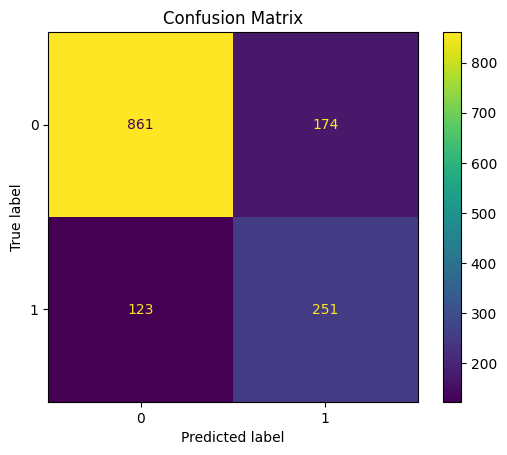

PR AUC Score: 0.660


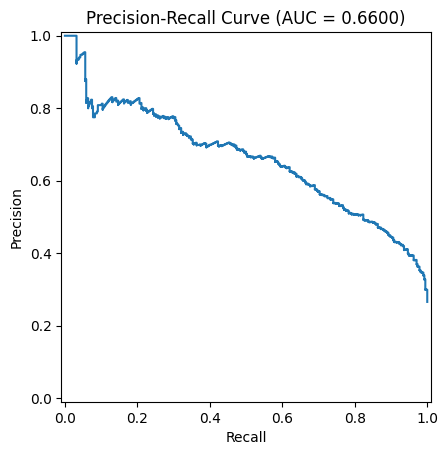

In [163]:
model_eval.evaluate_model(y_test, y_pred, y_proba)